In [37]:
import pandas as pd
df= pd.read_csv('M1045_MonthlyCrimeDashboard_TNOCrimeData.csv')
df.columns
#count is int64

Index(['Month_Year', 'Area Type', 'Borough_SNT', 'Area name', 'Area code',
       'Offence Group', 'Offence Subgroup', 'Measure', 'Financial Year',
       'FY_FYIndex', 'Count', 'Refresh Date'],
      dtype='object')

In [38]:
#recoding of borough variable
boroughs = [
    "Barking and Dagenham", "Barnet", "Bexley", "Brent", "Bromley",
    "Camden", "Croydon", "Ealing", "Enfield", "Greenwich",
    "Hackney", "Hammersmith and Fulham", "Haringey", "Harrow",
    "Havering", "Hillingdon", "Hounslow", "Islington",
    "Kensington and Chelsea", "Kingston upon Thames",
    "Lambeth", "Lewisham", "Merton", "Newham",
    "Redbridge", "Richmond upon Thames", "Southwark",
    "Sutton", "Tower Hamlets", "Waltham Forest",
    "Wandsworth", "Westminster",
    "City of London"]

def extract_borough(snt):
    for b in boroughs:
        if str(snt).startswith(b):
            return b
    #else goes on other
    return "Other/Undefined"
df["Borough"] = df["Borough_SNT"].apply(extract_borough)
df["Borough"].value_counts()

Borough
Croydon                   30894
Lambeth                   30843
Newham                    30590
Southwark                 28306
Enfield                   28062
Ealing                    28028
Barnet                    27380
Brent                     27236
Hackney                   27193
Greenwich                 27009
Tower Hamlets             26944
Wandsworth                25774
Haringey                  25761
Hounslow                  25728
Waltham Forest            25714
Lewisham                  25213
Camden                    24950
Redbridge                 24770
Westminster               24401
Hillingdon                23961
Bromley                   23901
Islington                 23219
Hammersmith and Fulham    22839
Barking and Dagenham      22274
Havering                  21614
Harrow                    20832
Kensington and Chelsea    20714
Merton                    19947
Sutton                    18590
Bexley                    18341
Richmond upon Thames      16973


In [39]:
#started analysis by looking at different variables
print(df['Borough'].value_counts())
borough = df[df['Area Type'] == 'Borough'].copy()
df['Borough'].nunique()

Borough
Croydon                   30894
Lambeth                   30843
Newham                    30590
Southwark                 28306
Enfield                   28062
Ealing                    28028
Barnet                    27380
Brent                     27236
Hackney                   27193
Greenwich                 27009
Tower Hamlets             26944
Wandsworth                25774
Haringey                  25761
Hounslow                  25728
Waltham Forest            25714
Lewisham                  25213
Camden                    24950
Redbridge                 24770
Westminster               24401
Hillingdon                23961
Bromley                   23901
Islington                 23219
Hammersmith and Fulham    22839
Barking and Dagenham      22274
Havering                  21614
Harrow                    20832
Kensington and Chelsea    20714
Merton                    19947
Sutton                    18590
Bexley                    18341
Richmond upon Thames      16973


33

In [40]:
print(df['Offence Group'].value_counts())
type('Month_Year') #this is str and must be converted for analysis
missing_counts= df.isnull().sum()
print('Is missing: ', missing_counts)
#Boroughs have 625 missing values+
#check duplicates
dupl= df.duplicated().sum()
print(dupl)

Offence Group
THEFT                                   126724
VIOLENCE AGAINST THE PERSON             109763
VEHICLE OFFENCES                         97203
PUBLIC ORDER OFFENCES                    89471
DRUG OFFENCES                            85215
BURGLARY                                 68681
SEXUAL OFFENCES                          55419
ARSON AND CRIMINAL DAMAGE                52983
ROBBERY                                  46825
MISCELLANEOUS CRIMES AGAINST SOCIETY     31176
POSSESSION OF WEAPONS                    27306
FRAUD AND FORGERY                          422
NFIB FRAUD                                  36
Name: count, dtype: int64
Is missing:  Month_Year             0
Area Type              0
Borough_SNT            0
Area name            625
Area code           3219
Offence Group          0
Offence Subgroup       0
Measure                0
Financial Year         0
FY_FYIndex             0
Count                  0
Refresh Date           0
Borough                0
dtype: int6

In [41]:
print(df['Measure'].unique())
print(df['Measure'].value_counts())
#confirm that count is numeric
print("Is count numeric:", pd.api.types.is_numeric_dtype(df['Count'])) 


['Positive Outcomes' 'Offences']
Measure
Offences             610723
Positive Outcomes    180501
Name: count, dtype: int64
Is count numeric: True


In [42]:
#Data cleaning
#convert date variable to datetime
import pandas as pd
df['Month_Year']= pd.to_datetime(df['Month_Year'], format= '%d/%m/%Y')
print(df['Month_Year'].head())

0   2021-06-01
1   2021-06-01
2   2021-06-01
3   2021-06-01
4   2021-06-01
Name: Month_Year, dtype: datetime64[ns]


In [43]:
#exclude positive outcome in measure
df1= df[df['Measure']== 'Offences'].copy()
print(df1['Measure'].value_counts())

Measure
Offences    610723
Name: count, dtype: int64


In [61]:
#check dataset
columns= ['Month_Year', 'Borough', 'Offence Group', 'Measure']# do i need to keep measure if the dataset is not limited to offences already?
combinations= df1.groupby(columns).size().reset_index(name='count')
duplic= combinations[combinations['count']>1] 
print(len(duplic))
if len(duplic) > 0: 
    print("Duplicated combinations (shouldn't happen):") 
    print(duplic) 
else: 
    print("Dataset is consistent.")

#So aggregate data:
df1_agg= df1.groupby(columns, as_index= False)['Count'].sum()
duplic2= df1_agg.duplicated(subset=columns).sum() 
print('Duplicates after agg: ', duplic2)

17556
Duplicated combinations (shouldn't happen):
      Month_Year               Borough                         Offence Group  \
0     2021-06-01  Barking and Dagenham             ARSON AND CRIMINAL DAMAGE   
1     2021-06-01  Barking and Dagenham                              BURGLARY   
2     2021-06-01  Barking and Dagenham                         DRUG OFFENCES   
3     2021-06-01  Barking and Dagenham  MISCELLANEOUS CRIMES AGAINST SOCIETY   
4     2021-06-01  Barking and Dagenham                 POSSESSION OF WEAPONS   
...          ...                   ...                                   ...   
17564 2025-05-01           Westminster                               ROBBERY   
17565 2025-05-01           Westminster                       SEXUAL OFFENCES   
17566 2025-05-01           Westminster                                 THEFT   
17567 2025-05-01           Westminster                      VEHICLE OFFENCES   
17568 2025-05-01           Westminster           VIOLENCE AGAINST THE 

In [66]:
#Feature Enginering
#create year month and season varaible
df1_agg['year']= df1_agg['Month_Year'].dt.year
df1_agg['month']= df1_agg['Month_Year'].dt.month
print(df1_agg['month'].unique())
season= {12: 'Winter', 1: 'Winter', 2: 'Winter',
         3: 'Spring', 4: 'Spring', 5: 'Spring',
         6: 'Summer', 7: 'Summer', 8: 'Summer',
         9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
df1_agg['season']= df1_agg['month'].map(season)
print(df1_agg['season'].unique())

[ 6  7  8  9 10 11 12  1  2  3  4  5]
['Summer' 'Autumn' 'Winter' 'Spring']


In [67]:
#create mean offences in boroughs per month variable
import numpy as np
borough_mean= df1_agg.groupby('Borough')['Count'].mean().reset_index()
borough_mean.sort_values(by='Count', ascending=False)
print(borough_mean)
#aggregate data
df_agg= (df1_agg.groupby(['Borough', 'Month_Year'])['Count'].sum().reset_index())
df_agg['log_count']= np.log(df_agg['Count'] + 1)
df_agg['time_idx']= df_agg['Month_Year'].rank(method='dense').astype(int)
df_agg['month']= df_agg['Month_Year'].dt.month

#linear regression
import statsmodels.formula.api as smf
model = smf.ols('log_count ~ time_idx + C(month) + C(Borough)', data=df_agg).fit()
print(model.summary())
df_agg['pred_log'] = model.fittedvalues
df_agg['pred_count'] = np.exp(df_agg['pred_log']) - 1

#aggregate predictions of tots
month_pred= (df_agg.groupby('Month_Year')['pred_count'].sum().reset_index())
month_obs = (df_agg.groupby('Month_Year')['Count'].sum().reset_index())



                   Borough        Count
0     Barking and Dagenham   300.773585
1                   Barnet   412.351504
2                   Bexley   241.058491
3                    Brent   456.511278
4                  Bromley   346.538318
5                   Camden   561.189493
6                  Croydon   500.095149
7                   Ealing   451.567669
8                  Enfield   439.052632
9                Greenwich   405.788679
10                 Hackney   473.405607
11  Hammersmith and Fulham   309.026168
12                Haringey   427.913696
13                  Harrow   232.099624
14                Havering   294.449905
15              Hillingdon   398.913371
16                Hounslow   382.537736
17               Islington   424.559099
18  Kensington and Chelsea   323.030019
19    Kingston upon Thames   175.212121
20                 Lambeth   526.274436
21                Lewisham   430.445283
22                  Merton   205.124060
23                  Newham   546.585821


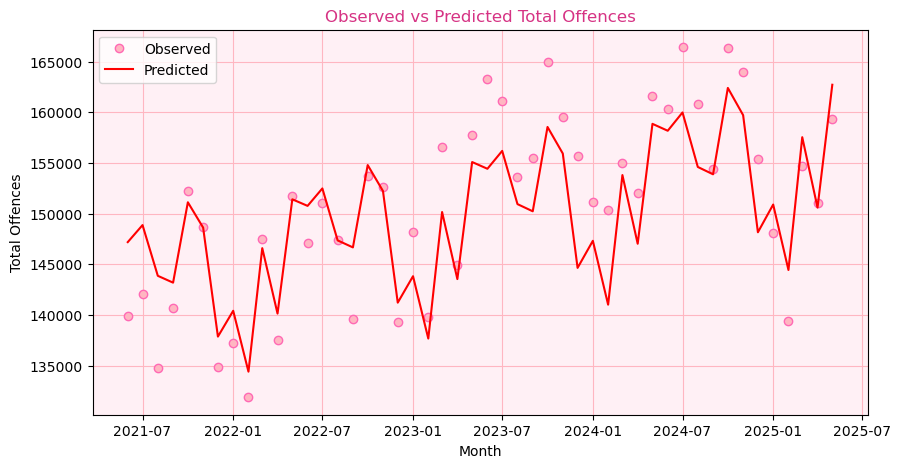

In [68]:
#Questions 1: How have total recorded offences changed across years?
import matplotlib.pyplot as plt
plt.figure(figsize= (10,5))
plt.plot(month_obs['Month_Year'], month_obs['Count'], 'o', label='Observed',
         color= '#ff69b4', markerfacecolor='#ffb6c1', markeredgecolor='#ff69b4')
plt.plot(month_pred['Month_Year'], month_pred['pred_count'], '-', label='Predicted', color='red')
plt.gca().set_facecolor('#fff0f5')
plt.title('Observed vs Predicted Total Offences', color='#d63384') 
plt.xlabel('Month') 
plt.ylabel('Total Offences') 
plt.grid(True, color='#ffb6c1')
plt.legend()
plt.show()

In [69]:
#Analysis at borough level
 #aggregate monthly total off per borough
import pandas as pd
agregate_data= (df1_agg.groupby(['Borough', 'Month_Year'])['Count'].sum().reset_index().sort_values(['Borough', 'Month_Year']))
agregate_data['time_idx']= (agregate_data.groupby('Borough').cumcount()+1)

#log transform
import statsmodels.api as sm
agregate_data['log_count']= np.log(agregate_data['Count']+1)
def trend(group):
    x= sm.add_constant(group['time_idx'])
    y= group['log_count']
    model= sm.OLS(y,x).fit()
    return pd.Series({'trend_slope': model.params['time_idx']})
trend_results= (agregate_data.groupby('Borough')[['time_idx', 'log_count']].apply(trend).reset_index())
print(trend_results)
#print model rsqu
x1= sm.add_constant(agregate_data[['time_idx']])
y = agregate_data['log_count']
model1= sm.OLS(y,x1).fit()
print('Model 1 (only time) r sqaured', model1.rsquared)



#dummy variable for borough
dum_borough= pd.get_dummies(agregate_data['Borough'], drop_first=True).astype(float)
#combine to main dataste
x2= pd.concat([agregate_data[['time_idx']], dum_borough], axis= 1)
x2=sm.add_constant(x2)
model2= sm.OLS(y,x2).fit()
print(model2.summary())
print('Model 2 (time and boroguh)r rquared', model2.rsquared)
#model comparison
pd.DataFrame({'Model': ['Time only', 'Time + Borough FE'],
              'R_squared': [model1.rsquared, model2.rsquared]})

                   Borough  trend_slope
0     Barking and Dagenham    -0.000059
1                   Barnet    -0.000545
2                   Bexley     0.000474
3                    Brent     0.002044
4                  Bromley     0.000464
5                   Camden     0.006948
6                  Croydon     0.000322
7                   Ealing     0.001593
8                  Enfield    -0.001261
9                Greenwich     0.000841
10                 Hackney    -0.000271
11  Hammersmith and Fulham     0.000870
12                Haringey    -0.001762
13                  Harrow     0.000896
14                Havering     0.001240
15              Hillingdon     0.002701
16                Hounslow     0.001707
17               Islington     0.003399
18  Kensington and Chelsea     0.002024
19    Kingston upon Thames    -0.002340
20                 Lambeth     0.002976
21                Lewisham     0.001341
22                  Merton    -0.000619
23                  Newham     0.003857


,Model,R_squared
0,Time only,0.003470
1,Time + Borough FE,0.933843


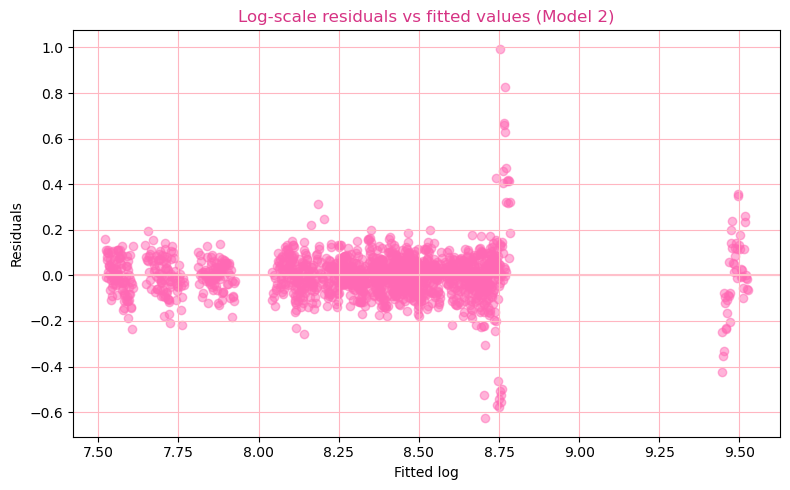

In [51]:
#Validation of model
#extract residuals
import matplotlib.pyplot as plt
residuals= model2.resid
fitted= model2.fittedvalues
plt.figure(figsize= (8,5))
plt.scatter(fitted, residuals, alpha= 0.5, color= '#ff69b4')
plt.axhline(0, color='pink')
plt.title('Log-scale residuals vs fitted values (Model 2)', color='#d63384') 
plt.xlabel('Fitted log') 
plt.ylabel('Residuals') 
plt.grid(True, color='#ffb6c1')
plt.tight_layout()
plt.show()



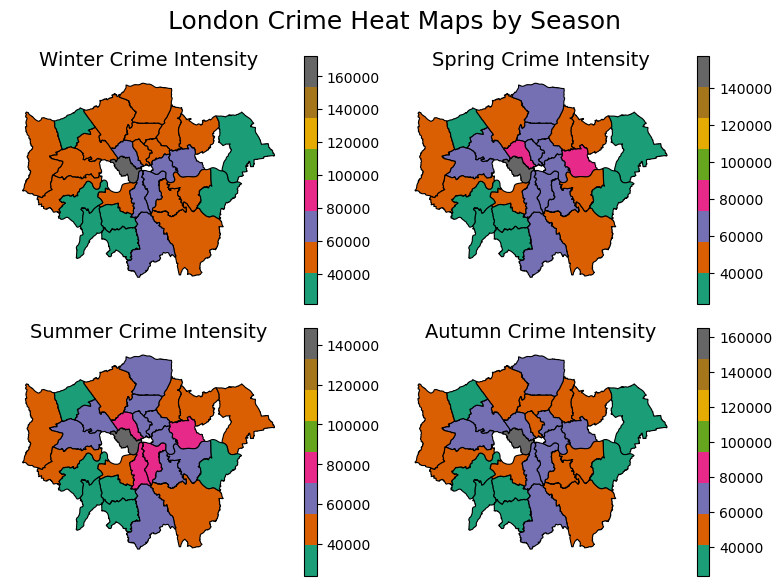

In [105]:
#Heat map of london
season_agg = (df1_agg.groupby(['Borough', 'season'])['Count'].sum().reset_index())
seasons = ["Winter", "Spring", "Summer", "Autumn"]
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
map_df = borough_gdf.merge(season_agg, on='Borough', how='left')
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()
for i, season in enumerate(seasons):
    ax = axes[i]
    season_map = map_df[map_df['season'] == season]
    season_map.plot(
        column='Count',
        cmap='Dark2',
        linewidth=0.8,
        edgecolor='black',
        legend=True,
        ax=ax)
    
    ax.set_title(f"{season} Crime Intensity", fontsize=14)
    ax.set_axis_off()

plt.suptitle("London Crime Heat Maps by Season", fontsize=18)
plt.tight_layout()
plt.show()


C:\Users\utente\anaconda3\condaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Clusters:                         cluster
Borough                        
Barking and Dagenham          0
Barnet                        0
Bexley                        0
Brent                         3
Bromley                       0
Camden                        2
Croydon                       3
Ealing                        3
Enfield                       0
Greenwich                     3
Hackney                       3
Hammersmith and Fulham        0
Haringey                      0
Harrow                        0
Havering                      0
Hillingdon                    3
Hounslow                      3
Islington                     3
Kensington and Chelsea        3
Kingston upon Thames          0
Lambeth                       3
Lewisham                      3
Merton                        0
Newham                        2
Redbridge                     0
Richmond upon Thames          0
Southwark                     2
Sutton                        0
Tower Hamlets                 

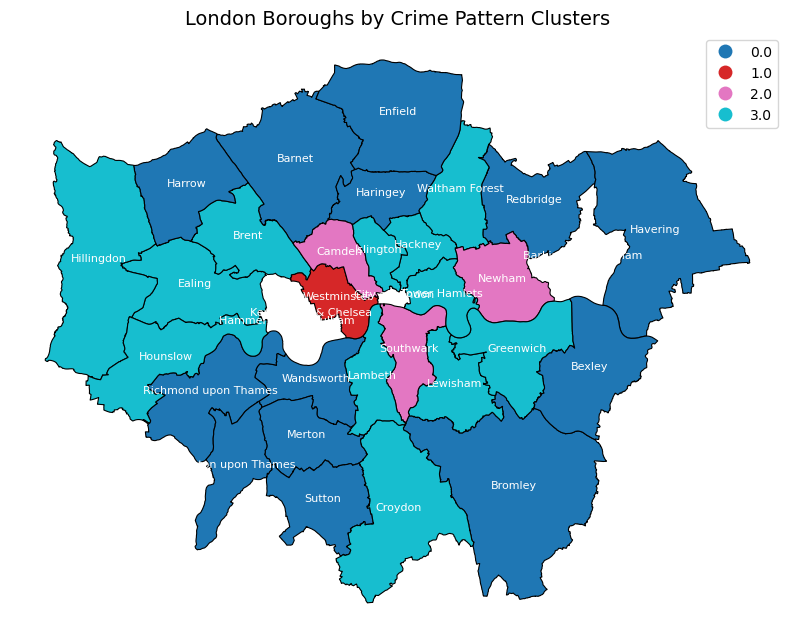

In [96]:
#Question 3:How can London boroughs be grouped into distinct clusters based on similarities in crime volume and seasonal patterns?
#create borough features
borough_features = pd.DataFrame({ 'mean_count': df1_agg.groupby('Borough')['Count'].mean(), 
                                  'season_amp': df1_agg.groupby('Borough')['Count'].agg(lambda x: x.max() - x.min()), 
                                  'trend_slope': trend_results.set_index('Borough')['trend_slope'] })
#season proportions
season_props= (df1_agg.groupby(['Borough', 'season'])['Count'].sum().groupby(level=0).apply(lambda x: x/ x.sum()).unstack(fill_value=0))
borough_features.index = borough_features.index.droplevel(1) if isinstance(borough_features.index, pd.MultiIndex) else borough_features.index
borough_features = borough_features.drop("Other/Undefined", errors="ignore")
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_scaled= scaler.fit_transform(borough_features)
#Kmeans
from sklearn.cluster import KMeans
kmeans= KMeans(n_clusters= 4, random_state=42)
borough_features['cluster']= kmeans.fit_predict(x_scaled)
borough_features.groupby('cluster').mean()
print('Clusters:', borough_features[['cluster']])
print('Cluster Centroid Feature Means', borough_features.groupby('cluster').mean())
print('KMeans Inertia', kmeans.inertia_)
import geopandas as gpd

borough_gdf= gpd.read_file('London_Boroughs.geojson')
borough_gdf= borough_gdf.rename(columns={'BOROUGH': 'Borough'})
#merge file
map_df = borough_gdf.merge(borough_features[['cluster']], left_on='Borough', right_index=True, how='left')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
fig, ax = plt.subplots(1, 1, figsize=(10,10))
map_df.plot(column='cluster', categorical=True, legend=True,
            linewidth=0.8, edgecolor='black', ax=ax)
for idx, row in map_df.iterrows():
    plt.annotate(text=row['Borough'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                 ha='center', fontsize=8, color='white')

plt.title("London Boroughs by Crime Pattern Clusters", fontsize=14)
plt.axis('off')
plt.show()      

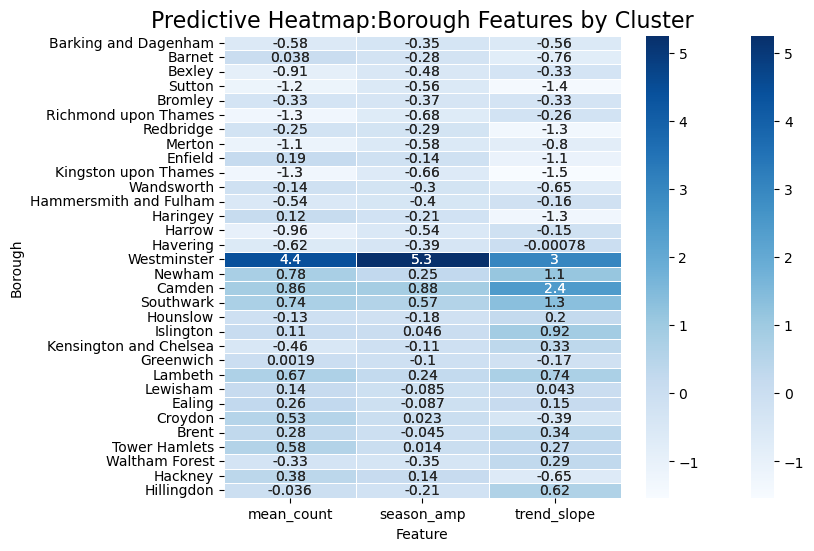

In [72]:
#Heatmap matrix style
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
features_heat= borough_features[['mean_count', 'season_amp', 'trend_slope']].copy()
scaler = StandardScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features_heat), index=features_heat.index, columns=features_heat.columns)
features_scaled['cluster'] = borough_features['cluster'].astype(str)
features_scaled = features_scaled.sort_values('cluster')

plt.figure(figsize=(8,6))
sns.heatmap(features_scaled.drop (columns='cluster'), cmap='Blues', linewidths=0.5, annot=True)
colors = features_scaled['cluster'].map({'0':'#ff9999', '1':'#66b3ff', '2':'#99ff99', '3':'#ffcc99'})
sns.heatmap(features_scaled.drop(columns='cluster'), cmap='Blues', linewidths=0.5, annot=True)
plt.title('Predictive Heatmap:Borough Features by Cluster', fontsize=16)
plt.xlabel('Feature')
plt.ylabel('Borough')
plt.show()

C:\Users\utente\anaconda3\condaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Clusters:           mean_count    season_amp  trend_slope
cluster                                        
0         299.807696   1199.133333    -0.000411
1         454.752468   2182.500000     0.002351
2        1201.252336  12875.000000     0.008268


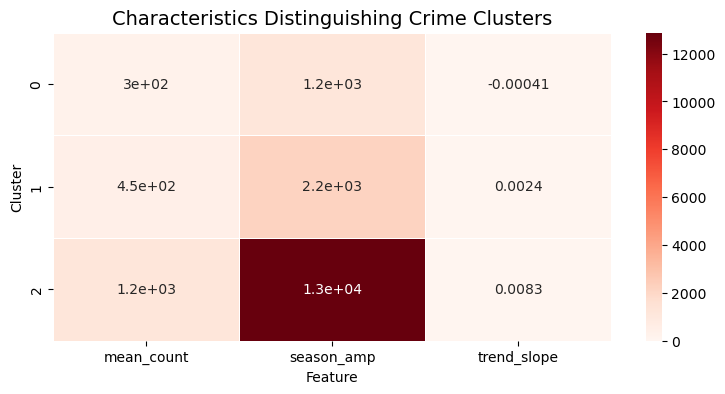

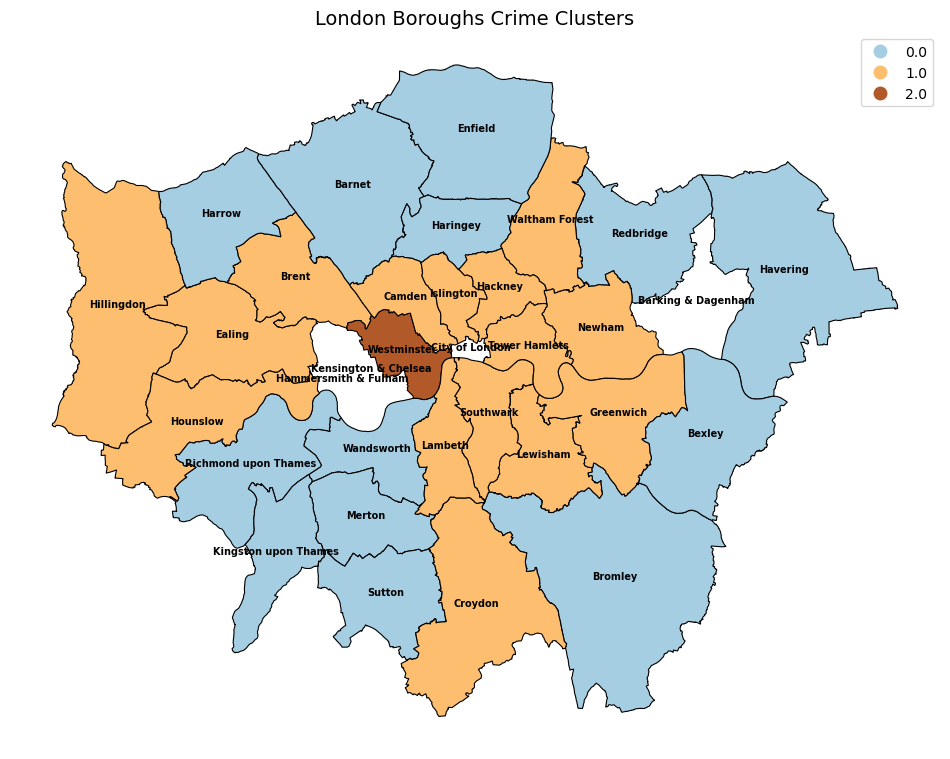

In [107]:
#Clustering-predictive
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
imputer=SimpleImputer(strategy='mean')
borough_features_imp= pd.DataFrame(imputer.fit_transform(borough_features),
                                   index=borough_features.index,
                                   columns=borough_features.columns)
#standardising features first
scaler= StandardScaler()
borough_scaled= pd.DataFrame(scaler.fit_transform(borough_features_imp),
                              index=borough_features_imp.index,
                              columns=borough_features_imp.columns)
#kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
borough_features_imp['cluster'] = kmeans.fit_predict(borough_scaled)
summary=borough_features_imp.groupby('cluster').mean()
print('Clusters:', summary)
import matplotlib.pyplot as plt
summary = borough_features_imp.groupby('cluster').mean()
import seaborn as sns
plt.figure(figsize=(9,4))
sns.heatmap(summary, annot=True, cmap='Reds', linewidths=0.5)
plt.title('Characteristics Distinguishing Crime Clusters', fontsize=14)
plt.ylabel('Cluster')
plt.xlabel('Feature')
plt.show()

import geopandas as gpd

borough_gdf= gpd.read_file('London_Boroughs.geojson')
borough_gdf= borough_gdf.rename(columns={'BOROUGH': 'Borough'})
#merge file
map_df = borough_gdf.merge(borough_features_imp[['cluster']], left_on='Borough', right_index=True, how='left')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
fig, ax = plt.subplots(1, 1, figsize=(12,12))
map_df.plot(column='cluster', categorical=True, legend=True, cmap= 'Paired',
            linewidth=0.8, edgecolor='black', ax=ax)
for idx, row in map_df.iterrows():
    plt.annotate(text=row['Borough'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                 ha='center', fontsize=7, color='black', fontweight='bold')

plt.title("London Boroughs Crime Clusters", fontsize=14)
plt.axis('off')
plt.show()      

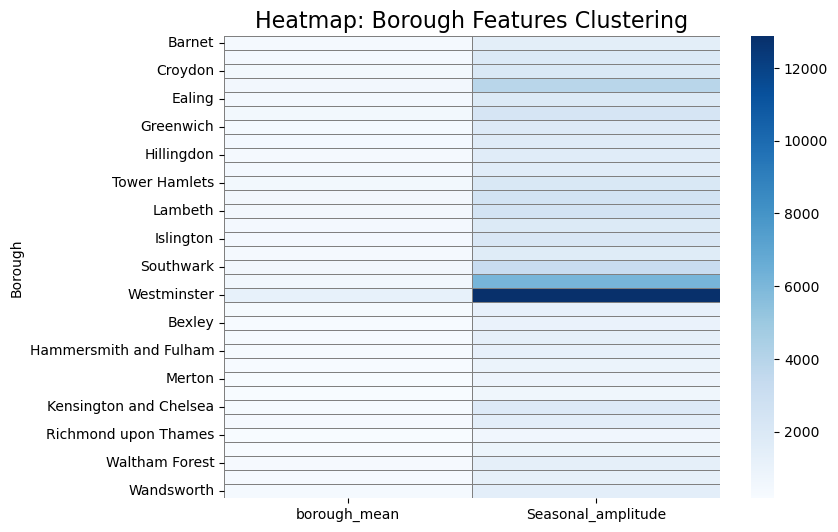

In [384]:
#heatmap
heatmap= borough_features_clean.copy()
heatmap['cluster']= borough_features_clean['cluster']
plt.figure(figsize=(8,6))
sns.heatmap(heatmap.sort_values('cluster')[['borough_mean','Seasonal_amplitude']],
            annot=False, fmt='.0f', cmap='Blues', linewidths=0.5, linecolor='grey')

plt.title('Heatmap: Borough Features Clustering', fontsize=16)
plt.show()

In [390]:
#Validation
#checking sensitivity of kmeans to scale
import numpy as np
log= borough_features_clean.copy()
log[['borough_mean','Seasonal_amplitude']]= np.log1p(log[['borough_mean','Seasonal_amplitude']])
#standardise
x_scaled_log= pd.DataFrame(StandardScaler().fit_transform(log), 
                       index=log.index, columns=log.columns)

kmeans = KMeans(n_clusters=3, random_state=42)
log['cluster'] = kmeans.fit_predict(x_scaled_log)
print('Logarithmic Clusters:', log)


Logarithmic Clusters:                         borough_mean  Seasonal_amplitude  cluster
Borough                                                          
Barking and Dagenham        5.709677            7.202661        2
Barnet                      6.024298            7.302496        0
Bexley                      5.489179            6.965080        1
Brent                       6.125802            7.582229        0
Bromley                     5.850875            7.160069        2
Camden                      6.331839            8.258422        0
Croydon                     6.216796            7.651596        0
Ealing                      6.114937            7.537430        0
Enfield                     6.086894            7.474772        0
Greenwich                   6.008294            7.519150        0
Hackney                     6.162063            7.763021        0
Hammersmith and Fulham      5.736657            7.114769        2
Haringey                    6.061256            7.3920

C:\Users\utente\anaconda3\condaa\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
### AI USE##
#Prompts:
#I need help performing a consistency check making sure that the dataset isnt double counting. How do I write this code?
#Help me write a function to compute a slope for each borough
#Can you add names for each borough in my map?
